
Milestone 1

In [ ]:
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Install dependencies
!pip install -q torch torchvision
!pip install -q transformers
!pip install -q pycocotools pillow tqdm matplotlib

In [2]:
import warnings
warnings.filterwarnings('ignore')

import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 50)
print("1. PyTorch")
print("=" * 50)
print(f"   Version:  {torch.__version__}")
print(f"   Device:   {DEVICE}")
if DEVICE == "cuda":
    print(f"   GPU:      {torch.cuda.get_device_name(0)}")
    print(f"   Memory:   {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   WARNING: No GPU detected! Go to Runtime > Change runtime type > T4 GPU")


# Hugging Face Transformers setup
import transformers
from transformers import GPT2Tokenizer, GPT2LMHeadModel

print("\n" + "=" * 50)
print("2. Hugging Face Transformers")
print("=" * 50)
print(f"   Version:  {transformers.__version__}")

#load GPT-2 tokenizer
_test_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
print(f"   GPT-2 tokenizer: OK (vocab size: {_test_tokenizer.vocab_size})")
del _test_tokenizer


#CLIP setup (via Hugging Face)
from transformers import CLIPModel, CLIPProcessor

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

print("\n" + "=" * 50)
print("3. CLIP (via Hugging Face)")
print("=" * 50)
print(f"   Model:    {CLIP_MODEL_NAME}")

#load CLIP processor
_test_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
print(f"   Processor: OK")
print(f"   Image size: {_test_processor.image_processor.size}")
del _test_processor


#Supporting libraries
import os
import json
import random
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from pycocotools.coco import COCO
import matplotlib.pyplot as plt

print("\n" + "=" * 50)
print("4. Supporting Libraries")
print("=" * 50)
print(f"   PIL (Pillow):   OK")
print(f"   pycocotools:    OK")
print(f"   matplotlib:     OK")


#Constants & reproducibility
SEED = 42
SUBSET_SIZE = 5000
MAX_CAPTION_LEN = 64

random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("/content/drive/MyDrive/image-captioning/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("\n" + "=" * 50)
print("5. Configuration")
print("=" * 50)
print(f"   Seed:             {SEED}")
print(f"   Subset size:      {SUBSET_SIZE}")
print(f"   Max caption len:  {MAX_CAPTION_LEN} tokens")
print(f"   Data directory:   {DATA_DIR}")
print("\n Finished")

1. PyTorch
   Version:  2.10.0+cu128
   Device:   cuda
   GPU:      Tesla T4
   Memory:   15.6 GB

2. Hugging Face Transformers
   Version:  5.0.0


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

   Processor: OK
   Image size: {'shortest_edge': 224}

4. Supporting Libraries
   PIL (Pillow):   OK
   pycocotools:    OK
   matplotlib:     OK

5. Configuration
   Seed:             42
   Subset size:      5000
   Max caption len:  64 tokens
   Data directory:   /content/drive/MyDrive/image-captioning/data

 Finished


Download , clean and Preprocess the dataset

In [3]:

#DOWNLOAD & PREPROCESS COCO CAPTIONS


import os
import random
from pathlib import Path
from pycocotools.coco import COCO
from google.colab import drive

#Download images & annotations to Google Drive

# Force remount to fix potential IOError
drive.mount("/content/drive", force_remount=True)

DATA_DIR = Path("/content/drive/MyDrive/image-captioning/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

IMG_DIR = DATA_DIR / "train2017"
ANN_DIR = DATA_DIR / "annotations"

if not IMG_DIR.exists():
    print("Downloading COCO train2017 images (this takes ~15-20 min)...")
    os.system("wget -q http://images.cocodataset.org/zips/train2017.zip -P /content/")
    os.system(f"unzip -q /content/train2017.zip -d {DATA_DIR}/")
    os.system("rm /content/train2017.zip")  # free up space
    print("Images downloaded & extracted.")
else:
    print(f"Images already exist at {IMG_DIR}, skipping download.")

if not ANN_DIR.exists():
    print("Downloading COCO annotations...")
    os.system("wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P /content/")
    os.system(f"unzip -q /content/annotations_trainval2017.zip -d {DATA_DIR}/")
    os.system("rm /content/annotations_trainval2017.zip")
    print("Annotations downloaded & extracted.")
else:
    print(f"Annotations already exist at {ANN_DIR}, skipping download.")

ANN_FILE = ANN_DIR / "captions_train2017.json"

# Make sure everything downloaded correctly
if not ANN_FILE.exists():
    raise FileNotFoundError(f"Annotations not found at {ANN_FILE}")
if not IMG_DIR.exists():
    raise FileNotFoundError(f"Images not found at {IMG_DIR}")


#Load annotations & sample 5k unique images
coco = COCO(str(ANN_FILE))
all_img_ids = list(coco.imgs.keys())
print(f"Total images in COCO train2017: {len(all_img_ids)}")

# Constants needed if previous cell wasn't run
SUBSET_SIZE = 5000
SEED = 42
random.seed(SEED)

# Randomly pick 5000 images
sampled_ids = sorted(random.sample(all_img_ids, SUBSET_SIZE))
print(f"Sampled subset: {len(sampled_ids)} images")


# Build (image_path, caption) pairs
# For each sampled image, grab the first caption and pair them together.
pairs = []
skipped = 0

print("Building dataset pairs...")
for img_id in sampled_ids:
    # Get image filename from COCO metadata
    info = coco.imgs[img_id]
    fname = info["file_name"]
    path = IMG_DIR / fname

    # Skip if the image file is missing
    # Wrapped in try-except to handle transient IOErrors from Drive
    try:
        if not path.exists():
            skipped += 1
            continue
    except OSError as e:
        # If Drive is flaky, we might just skip this one or retry
        print(f"Warning: IO Error accessing {fname}: {e}")
        skipped += 1
        continue

    # Look up captions for this image and take the first one
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    caption = anns[0]["caption"].strip().lower()

    pairs.append({
        "image_id": img_id,
        "path": str(path),
        "caption": caption
    })

print(f"\nValid image–caption pairs: {len(pairs)}")
print(f"Skipped (missing files):   {skipped}")
print(f"\n--- First 3 examples ---")
for i, p in enumerate(pairs[:3]):
    print(f"  [{i}] Image: {Path(p['path']).name}")
    print(f"       Caption: {p['caption']}\n")

Mounted at /content/drive
Images already exist at /content/drive/MyDrive/image-captioning/data/train2017, skipping download.
Annotations already exist at /content/drive/MyDrive/image-captioning/data/annotations, skipping download.
loading annotations into memory...
Done (t=4.58s)
creating index...
index created!
Total images in COCO train2017: 118287
Sampled subset: 5000 images
Building dataset pairs...

Valid image–caption pairs: 2811
Skipped (missing files):   2189

--- First 3 examples ---
  [0] Image: 000000000196.jpg
       Caption: this table is filled with a variety of different dishes.

  [1] Image: 000000000247.jpg
       Caption: a small airplane that is on a runway

  [2] Image: 000000000368.jpg
       Caption: a young boy playing soccer on a grassy field



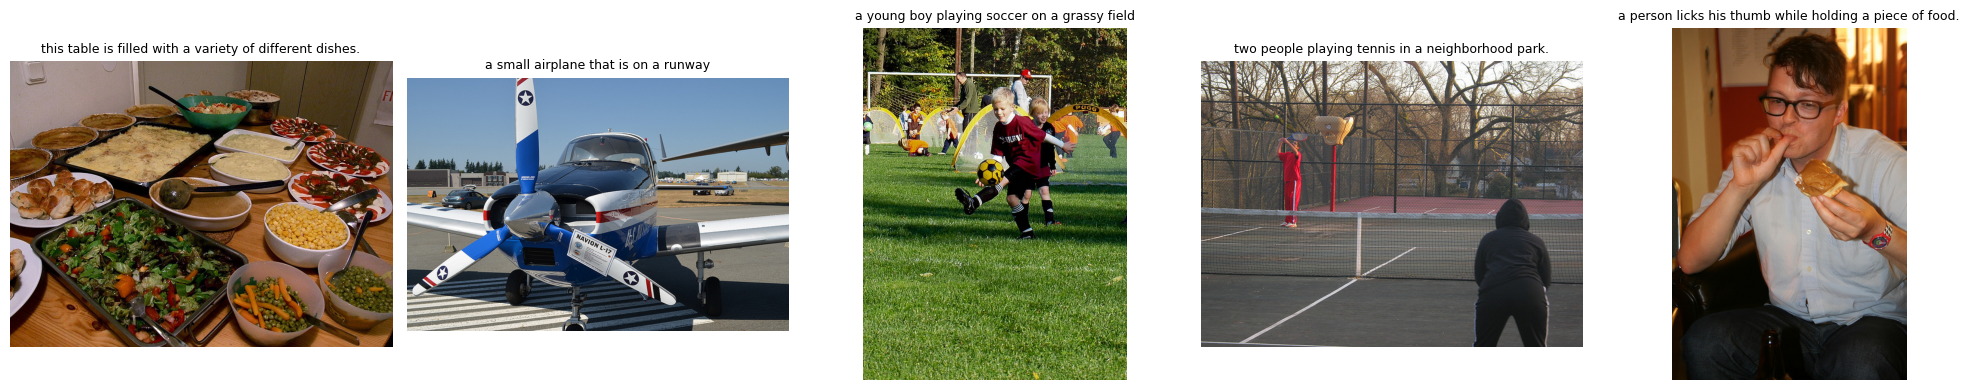

In [4]:
import matplotlib.pyplot as plt

def show_pairs(pairs, n=5):
    """Display n images with their captions side by side."""
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    for i, ax in enumerate(axes):
        img = Image.open(pairs[i]["path"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(pairs[i]["caption"], fontsize=9, wrap=True)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_pairs(pairs, n=5)

CLIP IMAGE EMBEDDING PIPELINE


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP model loaded: openai/clip-vit-base-patch32
Running on: cuda
Embedding dimension: 512

Encoding 2811 images...


CLIP encoding: 100%|██████████| 44/44 [37:15<00:00, 50.80s/it]


Done! Embeddings shape: torch.Size([2811, 512])

Sanity checks:
  Image 0 vs itself:   1.0000  ✅ (expect 1.0)
  Image 0 vs Image 1:  0.3896  ✅ (expect < 1.0)

Embedding stats:
  Mean:  -0.000430
  Std:   0.044192
  Min:   -0.802347
  Max:   0.393905

--- Similarity search examples ---


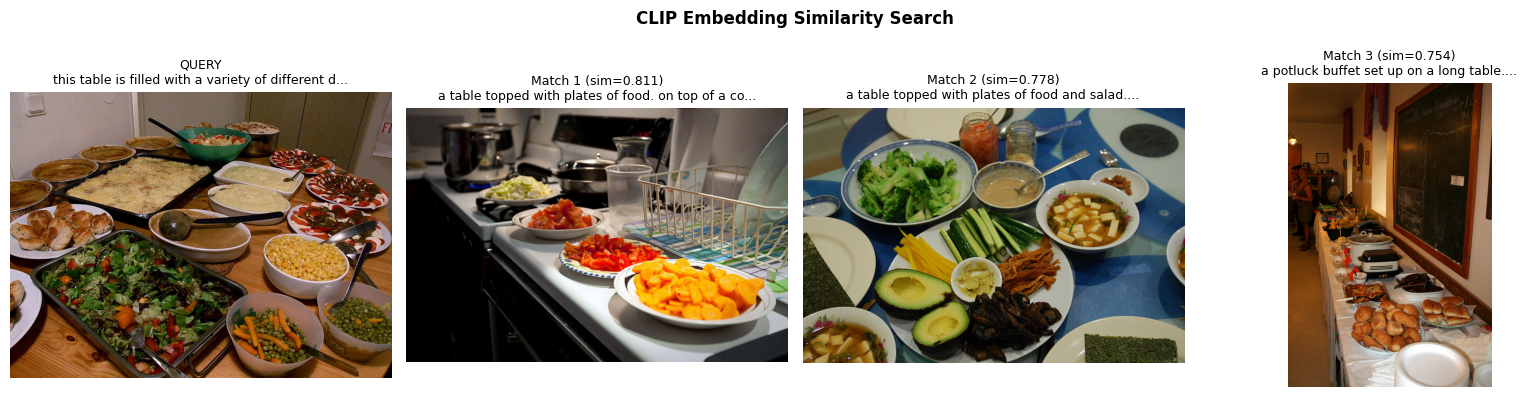

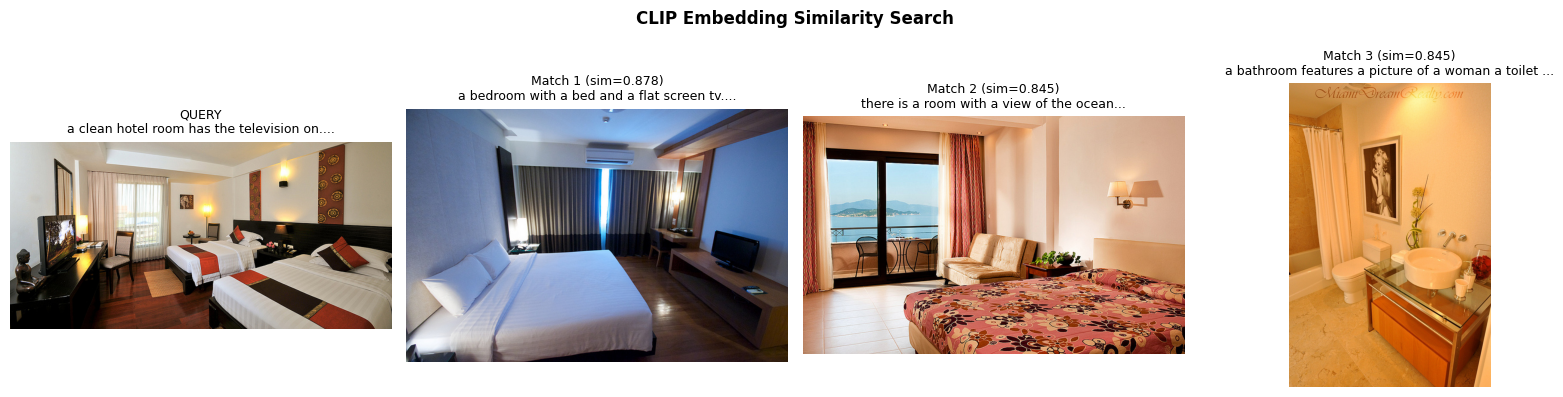

In [5]:

#CLIP IMAGE EMBEDDING PIPELINE

#Load CLIP model & processor


import torch
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from transformers import CLIPModel, CLIPProcessor

# Define constants locally in case previous cells were skipped
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model.eval()  # inference mode — no dropout, no training

EMB_DIM = clip_model.config.projection_dim  # 512

print(f"CLIP model loaded: {CLIP_MODEL_NAME}")
print(f"Running on: {DEVICE}")
print(f"Embedding dimension: {EMB_DIM}")


#Encode all 5k images into embeddings
@torch.no_grad()  # skip gradient tracking — saves memory & speeds up
def encode_images(pairs, batch_size=64):

    all_embs = []

    for i in tqdm(range(0, len(pairs), batch_size), desc="CLIP encoding"):
        # Grab a batch of file paths
        batch_paths = [p["path"] for p in pairs[i : i + batch_size]]

        # Open each image as RGB
        images = [Image.open(fp).convert("RGB") for fp in batch_paths]

        # CLIPProcessor handles all preprocessing automatically:
        #   - Resize to 224x224
        #   - Center crop
        #   - Convert to tensor
        #   - Normalize with CLIP's mean & std values
        inputs = clip_processor(images=images, return_tensors="pt").to(DEVICE)

        # Pass through CLIP's vision encoder → (batch_size, 512)
        outputs = clip_model.get_image_features(**inputs)

        # Some versions return a tensor directly, others return an object
        # This handles both cases safely
        embs = outputs if isinstance(outputs, torch.Tensor) else outputs.pooler_output

        # L2 normalize: scale each vector to length 1
        # After this, cosine similarity = simple dot product
        embs = embs / embs.norm(dim=-1, keepdim=True)

        # Move to CPU to free up GPU memory for next batch
        all_embs.append(embs.cpu())

    # Stack all batches into one tensor
    return torch.cat(all_embs, dim=0)

print(f"\nEncoding {len(pairs)} images...")
image_embeddings = encode_images(pairs)
print(f"Done! Embeddings shape: {image_embeddings.shape}")  # (5000, 512)


# Sanity checks
# Test 1: An image compared to itself should have similarity = 1.0
# Test 2: Two different images should have similarity < 1.0

cos = torch.nn.CosineSimilarity(dim=0)

sim_same = cos(image_embeddings[0], image_embeddings[0]).item()
sim_diff = cos(image_embeddings[0], image_embeddings[1]).item()

print(f"\nSanity checks:")
print(f"  Image 0 vs itself:   {sim_same:.4f}  ✅ (expect 1.0)")
print(f"  Image 0 vs Image 1:  {sim_diff:.4f}  ✅ (expect < 1.0)")

# Test 3: Check embedding statistics
print(f"\nEmbedding stats:")
print(f"  Mean:  {image_embeddings.mean().item():.6f}")
print(f"  Std:   {image_embeddings.std().item():.6f}")
print(f"  Min:   {image_embeddings.min().item():.6f}")
print(f"  Max:   {image_embeddings.max().item():.6f}")


#Visualize: similarity search
# Pick one image, find the 3 most similar images in our dataset
# based on CLIP embeddings. This proves the embeddings capture
# meaningful visual information.

def show_similar_pair(embeddings, pairs, idx=0, top_k=3):
    """Find and display the most similar images to pairs[idx]."""
    # Compare image[idx] against all other images
    sims = torch.nn.functional.cosine_similarity(
        embeddings[idx].unsqueeze(0), embeddings, dim=1
    )
    # Exclude self-match
    sims[idx] = -1
    top_indices = sims.argsort(descending=True)[:top_k]

    # Plot query + matches
    fig, axes = plt.subplots(1, top_k + 1, figsize=(4 * (top_k + 1), 4))

    # Query image (left)
    query_img = Image.open(pairs[idx]["path"]).convert("RGB")
    axes[0].imshow(query_img)
    axes[0].set_title(f"QUERY\n{pairs[idx]['caption'][:50]}...", fontsize=9)
    axes[0].axis("off")

    # Matched images (right)
    for j, match_idx in enumerate(top_indices):
        match_img = Image.open(pairs[match_idx]["path"]).convert("RGB")
        axes[j + 1].imshow(match_img)
        sim_score = sims[match_idx].item()
        axes[j + 1].set_title(
            f"Match {j+1} (sim={sim_score:.3f})\n{pairs[match_idx]['caption'][:50]}...",
            fontsize=9
        )
        axes[j + 1].axis("off")

    plt.suptitle("CLIP Embedding Similarity Search", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Try a few different query images
print("\n--- Similarity search examples ---")
show_similar_pair(image_embeddings, pairs, idx=0)
show_similar_pair(image_embeddings, pairs, idx=100)

In [6]:

#GPT-2 CAPTION TOKENIZATION



from transformers import GPT2Tokenizer

#Load tokenizer & add special tokens
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# GPT-2 doesn't have a pad token by default, so we add three
# special tokens for our captioning task
special_tokens = {
    "bos_token": "<|startofcaption|>",   # beginning of sequence
    "eos_token": "<|endofcaption|>",     # end of sequence
    "pad_token": "<|pad|>",              # padding
}
num_added = tokenizer.add_special_tokens(special_tokens)

print(f"GPT-2 base vocab size:  50257")
print(f"Special tokens added:   {num_added}")
print(f"New vocab size:         {len(tokenizer)}")
print(f"  START token: '{tokenizer.bos_token}' → ID {tokenizer.bos_token_id}")
print(f"  END token:   '{tokenizer.eos_token}' → ID {tokenizer.eos_token_id}")
print(f"  PAD token:   '{tokenizer.pad_token}' → ID {tokenizer.pad_token_id}")


#Tokenize all captions


MAX_CAPTION_LEN = 64  # max tokens per caption (including special tokens)

import torch

all_input_ids = []
all_attention_masks = []

print(f"\nTokenizing {len(pairs)} captions (max length: {MAX_CAPTION_LEN})...")

for i, pair in enumerate(tqdm(pairs, desc="Tokenizing")):
    # Wrap caption with special tokens
    text = f"{tokenizer.bos_token} {pair['caption']} {tokenizer.eos_token}"

    # Tokenize — this converts text → list of integer IDs
    encoded = tokenizer(
        text,
        max_length=MAX_CAPTION_LEN,
        padding="max_length",          # pad short captions to MAX_CAPTION_LEN
        truncation=True,               # cut long captions at MAX_CAPTION_LEN
        return_tensors="pt",           # return PyTorch tensors
        return_attention_mask=True,
    )

    all_input_ids.append(encoded["input_ids"].squeeze(0))          # shape: (64,)
    all_attention_masks.append(encoded["attention_mask"].squeeze(0))  # shape: (64,)

# Stack into single tensors
caption_input_ids = torch.stack(all_input_ids)          # (5000, 64)
caption_attention_masks = torch.stack(all_attention_masks)  # (5000, 64)

print(f"\nTokenization complete!")
print(f"  Input IDs shape:      {caption_input_ids.shape}")
print(f"  Attention masks shape: {caption_attention_masks.shape}")


#Sanity checks
print("\n--- Tokenization Examples ---")
for i in range(3):
    ids = caption_input_ids[i]
    mask = caption_attention_masks[i]
    real_tokens = mask.sum().item()  # count of non-padding tokens

    # Decode back to text to verify it looks right
    decoded = tokenizer.decode(ids[: real_tokens], skip_special_tokens=False)

    print(f"\n  [{i}] Original:  {pairs[i]['caption']}")
    print(f"      Tokens:    {real_tokens} real + {MAX_CAPTION_LEN - real_tokens} padding = {MAX_CAPTION_LEN} total")
    print(f"      IDs (first 10): {ids[:10].tolist()}")
    print(f"      Mask(first 10): {mask[:10].tolist()}")
    print(f"      Decoded:   {decoded}")

# Distribution of caption lengths (in tokens)
real_lengths = caption_attention_masks.sum(dim=1)  # how many real tokens per caption
print(f"\n--- Caption Length Stats (in tokens) ---")
print(f"  Min:    {real_lengths.min().item()}")
print(f"  Max:    {real_lengths.max().item()}")
print(f"  Mean:   {real_lengths.float().mean().item():.1f}")
print(f"  Median: {real_lengths.float().median().item():.1f}")

# Check how many captions got truncated
truncated = (real_lengths == MAX_CAPTION_LEN).sum().item()
print(f"  Truncated (hit max): {truncated} ({truncated/len(pairs)*100:.1f}%)")

print("\n" + "=" * 55)
print("Captions are now token IDs.")
print("=" * 55)




GPT-2 base vocab size:  50257
Special tokens added:   3
New vocab size:         50260
  START token: '<|startofcaption|>' → ID 50257
  END token:   '<|endofcaption|>' → ID 50258
  PAD token:   '<|pad|>' → ID 50259

Tokenizing 2811 captions (max length: 64)...


Tokenizing: 100%|██████████| 2811/2811 [00:00<00:00, 5088.85it/s]


Tokenization complete!
  Input IDs shape:      torch.Size([2811, 64])
  Attention masks shape: torch.Size([2811, 64])

--- Tokenization Examples ---

  [0] Original:  this table is filled with a variety of different dishes.
      Tokens:    14 real + 50 padding = 64 total
      IDs (first 10): [50257, 428, 3084, 318, 5901, 351, 257, 4996, 286, 1180]
      Mask(first 10): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
      Decoded:   <|startofcaption|> this table is filled with a variety of different dishes. <|endofcaption|>

  [1] Original:  a small airplane that is on a runway
      Tokens:    11 real + 53 padding = 64 total
      IDs (first 10): [50257, 257, 1402, 19401, 326, 318, 319, 257, 23443, 220]
      Mask(first 10): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
      Decoded:   <|startofcaption|> a small airplane that is on a runway <|endofcaption|>

  [2] Original:  a young boy playing soccer on a grassy field
      Tokens:    13 real + 51 padding = 64 total
      IDs (first 10): [50257, 257, 1862, 2933

In [7]:

#BUNDLE & SAVE EVERYTHING TO DISK


import json
from pathlib import Path

SAVE_DIR = Path("/content/drive/MyDrive/image-captioning/processed")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

#Save tensors (PyTorch format)
tensor_path = SAVE_DIR / "milestone1_tensors.pt"

save_data = {
    "image_embeddings": image_embeddings,            # (5000, 512)
    "caption_input_ids": caption_input_ids,          # (5000, 64)
    "caption_attention_masks": caption_attention_masks,  # (5000, 64)
    "vocab_size": len(tokenizer),                    # 50260
    "max_caption_len": MAX_CAPTION_LEN,              # 64
    "clip_emb_dim": image_embeddings.shape[1],       # 512
}

torch.save(save_data, tensor_path)
print(f"Tensors saved to: {tensor_path}")
print(f"  File size: {tensor_path.stat().st_size / 1e6:.1f} MB")

#Save metadata (JSON format)
meta_path = SAVE_DIR / "milestone1_metadata.json"

metadata = {
    "num_pairs": len(pairs),
    "subset_size": SUBSET_SIZE,
    "seed": SEED,
    "max_caption_len": MAX_CAPTION_LEN,
    "clip_model": "openai/clip-vit-base-patch32",
    "clip_emb_dim": 512,
    "vocab_size": len(tokenizer),
    "special_tokens": special_tokens,
    "pairs": pairs,  # includes image_id, path, caption for each
}

with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {meta_path}")
print(f"  File size: {meta_path.stat().st_size / 1e6:.1f} MB")

#Save tokenizer (so we can reload it exactly)
tok_path = SAVE_DIR / "tokenizer"
tokenizer.save_pretrained(str(tok_path))
print(f"Tokenizer saved to: {tok_path}")

#Final verification
print("\n--- Verification: reload and check shapes ---")
loaded = torch.load(tensor_path, weights_only=True)
print(f"  image_embeddings:       {loaded['image_embeddings'].shape}")
print(f"  caption_input_ids:      {loaded['caption_input_ids'].shape}")
print(f"  caption_attention_masks: {loaded['caption_attention_masks'].shape}")
print(f"  vocab_size:             {loaded['vocab_size']}")

# Quick sanity: first caption should decode correctly
reloaded_tokenizer = GPT2Tokenizer.from_pretrained(str(tok_path))
first_ids = loaded["caption_input_ids"][0]
first_mask = loaded["caption_attention_masks"][0]
real_len = first_mask.sum().item()
decoded = reloaded_tokenizer.decode(first_ids[:real_len], skip_special_tokens=False)
print(f"\n  First caption decoded: {decoded}")
print(f"  Original caption:      {pairs[0]['caption']}")

print("\n" + "=" * 55)
print("MILESTONE 1 COMPLETE!")
print("=" * 55)
print(f"""
  Everything is saved to Google Drive:
    📁 {SAVE_DIR}/
       ├── milestone1_tensors.pt    (embeddings + tokens)
       ├── milestone1_metadata.json (paths, captions, config)
       └── tokenizer/               (GPT-2 + special tokens)

  For Milestone 2, just load with:
    data = torch.load('{tensor_path}')
    tokenizer = GPT2Tokenizer.from_pretrained('{tok_path}')
""")

Tensors saved to: /content/drive/MyDrive/image-captioning/processed/milestone1_tensors.pt
  File size: 8.6 MB
Metadata saved to: /content/drive/MyDrive/image-captioning/processed/milestone1_metadata.json
  File size: 0.6 MB
Tokenizer saved to: /content/drive/MyDrive/image-captioning/processed/tokenizer

--- Verification: reload and check shapes ---
  image_embeddings:       torch.Size([2811, 512])
  caption_input_ids:      torch.Size([2811, 64])
  caption_attention_masks: torch.Size([2811, 64])
  vocab_size:             50260

  First caption decoded: <|startofcaption|> this table is filled with a variety of different dishes. <|endofcaption|>
  Original caption:      this table is filled with a variety of different dishes.

MILESTONE 1 COMPLETE!

  Everything is saved to Google Drive:
    📁 /content/drive/MyDrive/image-captioning/processed/
       ├── milestone1_tensors.pt    (embeddings + tokens)
       ├── milestone1_metadata.json (paths, captions, config)
       └── tokenizer/      